# Phase 1F: interior-threat / local-compression diagnostic

Metrica Sample Game 1 only. This notebook tests whether substantial local and opponent-relative defensive reorganization can occur while the defensive centroid remains approximately stable. It distinguishes **local compression around a threat** from provisional **relational exposure elsewhere**. Neither term is a score or tactical verdict.

Reception events are temporal anchors only. They are not labels, assignments, or proof that the receiver is tactically interior. Examples were fixed from full-team raw trajectories and labeled snapshots before any diagnostic quantity was calculated.

In [1]:
from pathlib import Path
import hashlib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'; HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]})

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3); ps=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ps: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ps
home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}; LENGTH=105.; WIDTH=68.
home.shape,away.shape,events.shape

((145006, 33), (145006, 33), (1745, 14))

## Fixed visual-first cases

The following windows were selected from raw trajectories and five labeled snapshots (−2, −1, 0, +1, +2 s). The receiver appeared inside a recognizable defensive cluster/depth interval, and several defenders visibly contracted toward that area. Event rows only located the reception time.

- **472.48 s:** focal Away Player19; visually converging Home Players6, 8, 10; contextual other attackers Away Players16, 24, 20.
- **1230.12 s:** focal Home Player10; visually converging Away Players19, 20, 21; contextual other attackers Home Players6, 7, 5.
- **4197.04 s:** focal Home Player10; visually converging Away Players16, 18, 21; contextual other attackers Home Players12, 6, 3.

The converging defenders and other attackers are manually fixed visual choices, not inferred assignments or nearest-opponent rules. Windows span ±2 s around each anchor.

In [3]:
CASES=[
 {'anchor':472.48,'period':1,'att_team':'Away','focal':'19','def_team':'Home','convergers':['6','8','10'],'others':['16','24','20']},
 {'anchor':1230.12,'period':1,'att_team':'Home','focal':'10','def_team':'Away','convergers':['19','20','21'],'others':['6','7','5']},
 {'anchor':4197.04,'period':2,'att_team':'Home','focal':'10','def_team':'Away','convergers':['16','18','21'],'others':['12','6','3']} ]
OFFSETS=[-2,-1,0,1,2]
def case_window(c):
    d=tracking[c['def_team']]; a=tracking[c['att_team']]; w=d[(d.Period==c['period'])&d['Time [s]'].between(c['anchor']-2,c['anchor']+2)].copy()
    ac=['Frame']+[f"{c['att_team']}_{p}_{axis}" for p in players[c['att_team']] for axis in ['x','y']]
    return w.merge(a[ac],on='Frame',validate='one_to_one')
def at_offset(w,c,offset): return w.loc[(w['Time [s]']-(c['anchor']+offset)).abs().idxmin()]
[(c['anchor'],case_window(c).shape) for c in CASES]

[(472.48, (101, 61)), (1230.12, (101, 61)), (4197.04, (101, 61))]

## Soccer-first snapshot sequences

Converging defenders are outlined and labeled; other defenders remain blue, all attackers remain red, the focal attacker is an orange star, the ball is black, and the outfield defensive centroid is a green diamond. Coordinates are shown in documented 105 × 68 m units without orientation flipping.

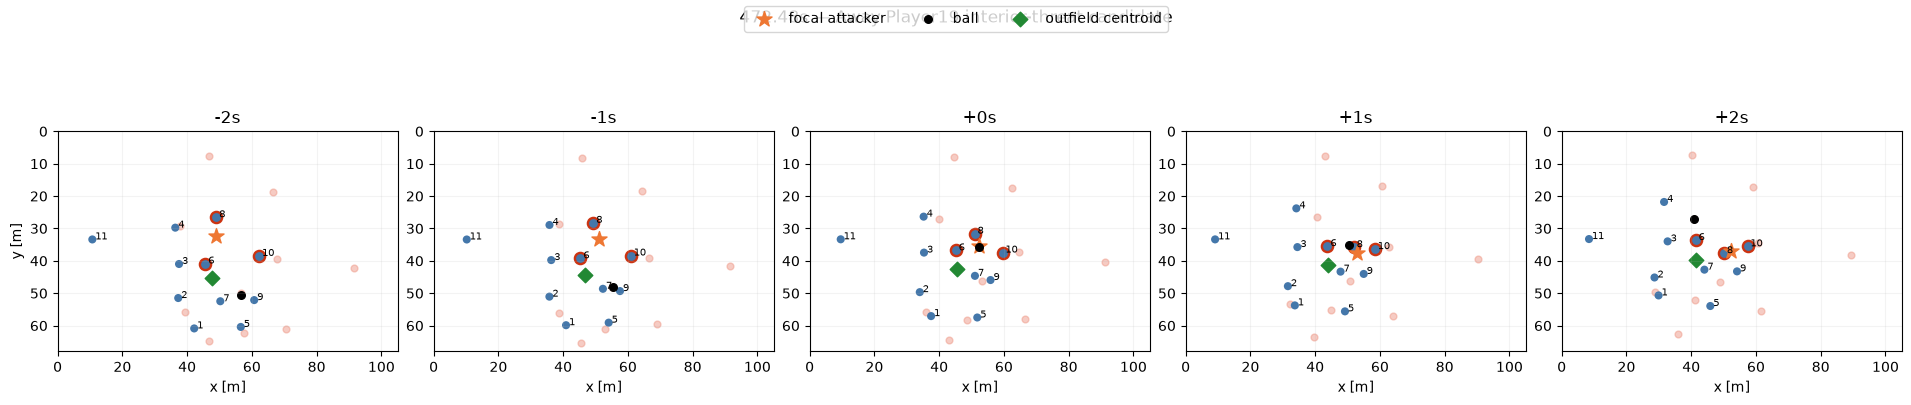

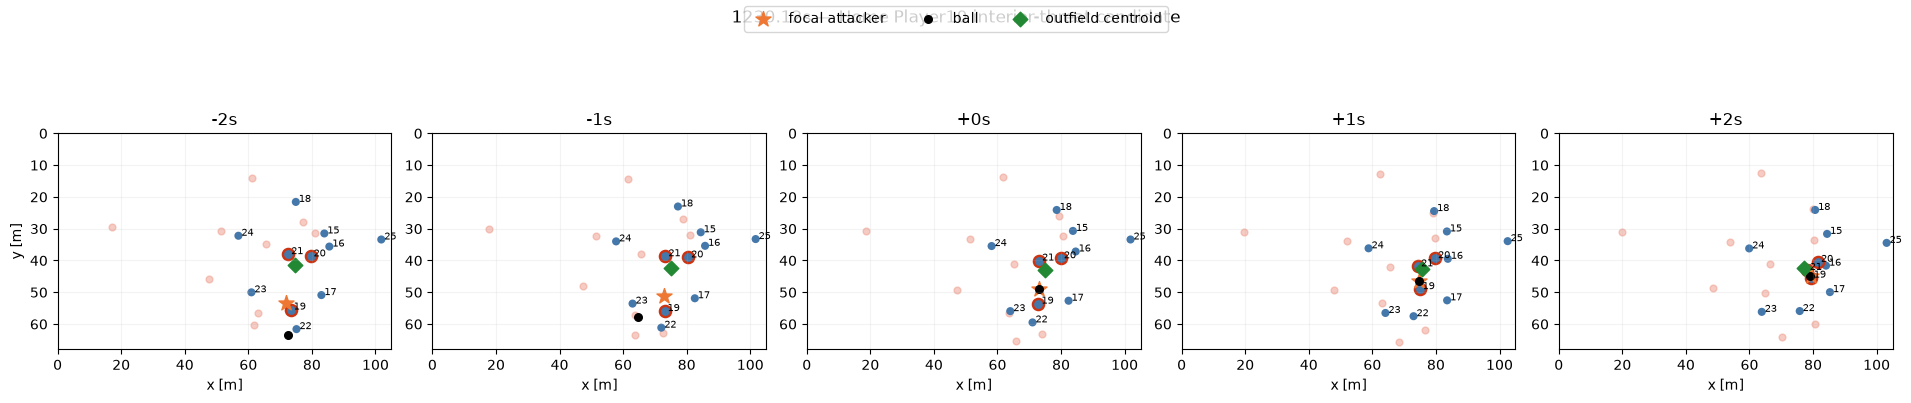

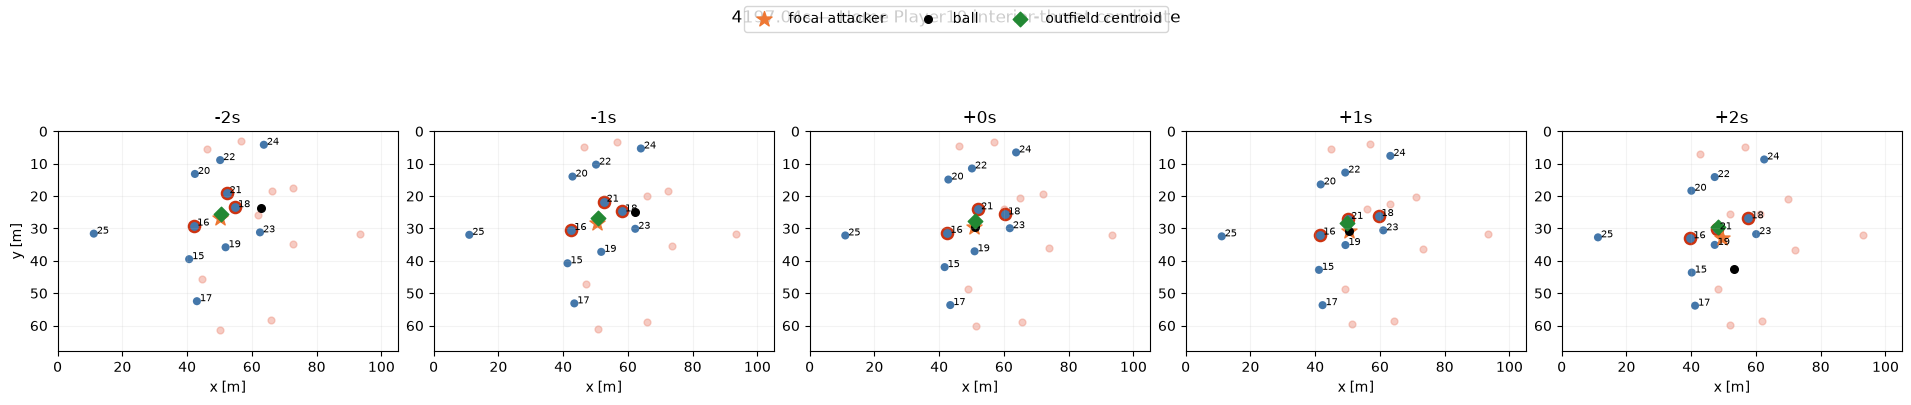

In [4]:
def snapshot_sequence(c):
    w=case_window(c); dt,at=c['def_team'],c['att_team']; outfield=[p for p in players[dt] if p!=goalkeeper[dt]]
    fig,axes=plt.subplots(1,5,figsize=(19,4),constrained_layout=True)
    for ax,off in zip(axes,OFFSETS):
        r=at_offset(w,c,off); cx=np.nanmean([r[f'{dt}_{p}_x'] for p in outfield])*LENGTH; cy=np.nanmean([r[f'{dt}_{p}_y'] for p in outfield])*WIDTH
        for p in players[at]: ax.scatter(r[f'{at}_{p}_x']*LENGTH,r[f'{at}_{p}_y']*WIDTH,c='#ee9988',s=24,alpha=.5)
        for p in players[dt]:
            conv=p in c['convergers']; ax.scatter(r[f'{dt}_{p}_x']*LENGTH,r[f'{dt}_{p}_y']*WIDTH,c='#4477aa',s=65 if conv else 34,edgecolor='#cc3311' if conv else 'none',linewidth=1.7); ax.text(r[f'{dt}_{p}_x']*LENGTH,r[f'{dt}_{p}_y']*WIDTH,f' {p}',fontsize=7)
        ax.scatter(r[f"{at}_{c['focal']}_x"]*LENGTH,r[f"{at}_{c['focal']}_y"]*WIDTH,c='#ee7733',marker='*',s=130,label='focal attacker'); ax.scatter(r[f'{dt}_ball_x']*LENGTH,r[f'{dt}_ball_y']*WIDTH,c='black',s=30,label='ball'); ax.scatter(cx,cy,c='#228833',marker='D',s=55,label='outfield centroid')
        ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',title=f'{off:+d}s',xlabel='x [m]'); ax.grid(alpha=.15)
    axes[0].set_ylabel('y [m]'); fig.legend(*axes[0].get_legend_handles_labels(),loc='upper center',ncol=3); fig.suptitle(f"{c['anchor']:.2f}s — {at} Player{c['focal']} interior-threat candidate",y=1.08); plt.show()
for c in CASES: snapshot_sequence(c)

## Centroid, local compression, and defensive geometry

The centroid includes all defending outfield players and excludes the goalkeeper. Centroid displacement is relative to −2 s. Threat distance is each fixed converger's distance to the focal attacker. Pair spacing retains all three converger pairs separately. Defender depth is x relative to the defensive centroid; it is a coordinate description, not a role or inferred line.

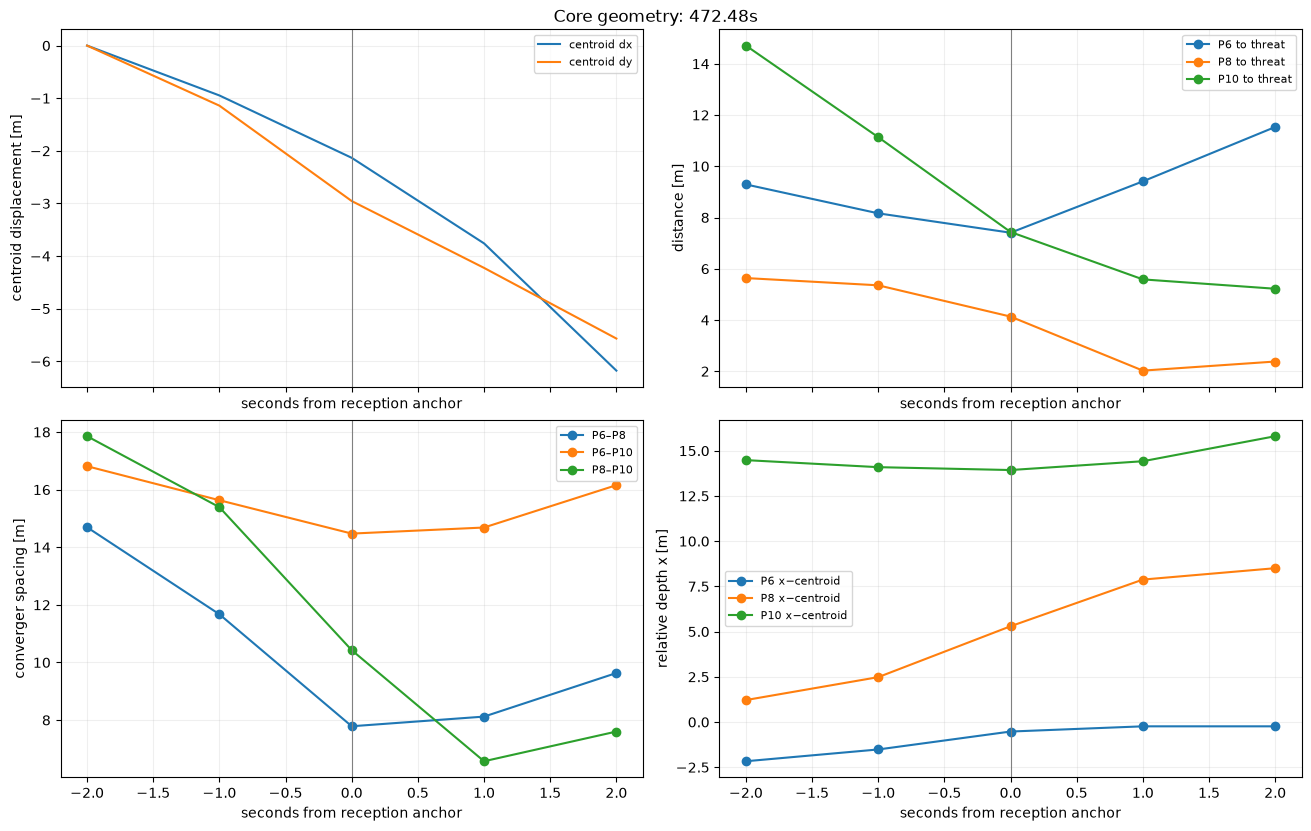

,offset_s,centroid_x_m,centroid_y_m,P6_threat_distance_m,P6_x_minus_centroid_m,P6_y_minus_centroid_m,P8_threat_distance_m,P8_x_minus_centroid_m,P8_y_minus_centroid_m,P10_threat_distance_m,P10_x_minus_centroid_m,P10_y_minus_centroid_m,P6_P8_spacing_m,P6_P10_spacing_m,P8_P10_spacing_m,centroid_dx_from_-2_m,centroid_dy_from_-2_m
0,-2,47.764,45.400,9.291,-2.167,-4.556,5.637,1.216,-18.854,14.710,14.482,-6.903,14.693,16.813,17.855,0.000,0.000
1,-1,46.817,44.259,8.164,-1.515,-5.021,5.355,2.483,-15.987,11.136,14.093,-5.884,11.672,15.632,15.391,-0.948,-1.142
2,0,45.632,42.446,7.407,-0.525,-5.662,4.134,5.297,-10.831,7.435,13.934,-4.991,7.785,14.474,10.426,-2.133,-2.954
3,1,44.006,41.176,9.411,-0.236,-5.705,2.025,7.877,-5.382,5.586,14.421,-4.798,8.120,14.685,6.570,-3.759,-4.224
4,2,41.588,39.834,11.533,-0.237,-6.227,2.380,8.507,-2.185,5.220,15.804,-4.310,9.632,16.155,7.600,-6.177,-5.567


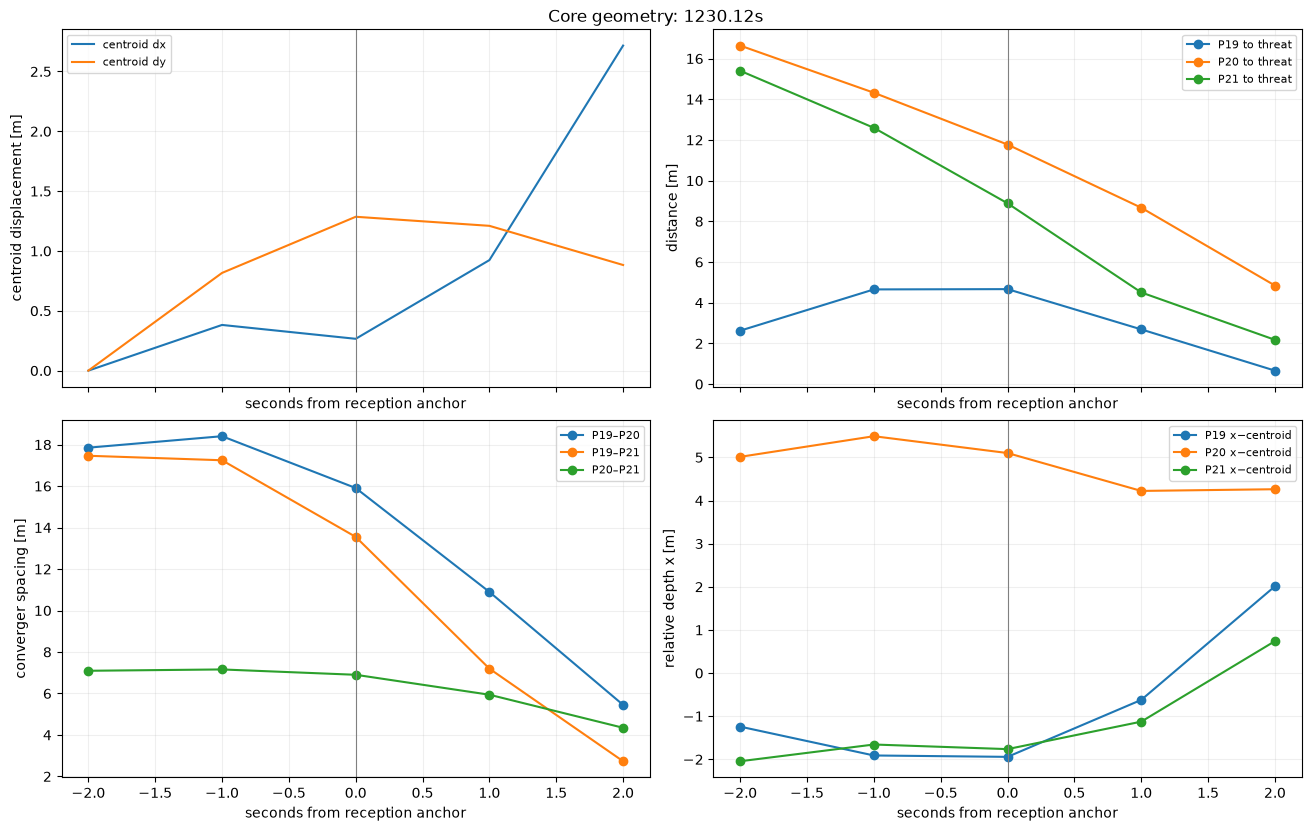

,offset_s,centroid_x_m,centroid_y_m,P19_threat_distance_m,P19_x_minus_centroid_m,P19_y_minus_centroid_m,P20_threat_distance_m,P20_x_minus_centroid_m,P20_y_minus_centroid_m,P21_threat_distance_m,P21_x_minus_centroid_m,P21_y_minus_centroid_m,P19_P20_spacing_m,P19_P21_spacing_m,P20_P21_spacing_m,centroid_dx_from_-2_m,centroid_dy_from_-2_m
0,-2,74.574,41.556,2.627,-1.242,13.888,16.638,5.013,-2.832,15.399,-2.044,-3.555,17.852,17.462,7.094,0.000,0.000
1,-1,74.956,42.372,4.654,-1.911,13.535,14.320,5.491,-3.316,12.595,-1.656,-3.709,18.405,17.245,7.158,0.382,0.817
2,0,74.840,42.842,4.668,-1.943,10.734,11.774,5.101,-3.528,8.886,-1.763,-2.815,15.906,13.550,6.901,0.266,1.286
3,1,75.498,42.766,2.690,-0.622,6.255,8.669,4.222,-3.505,4.506,-1.126,-0.923,10.896,7.196,5.939,0.924,1.210
4,2,77.291,42.439,0.663,2.012,2.955,4.845,4.262,-2.008,2.177,0.740,0.537,5.449,2.731,4.345,2.716,0.883


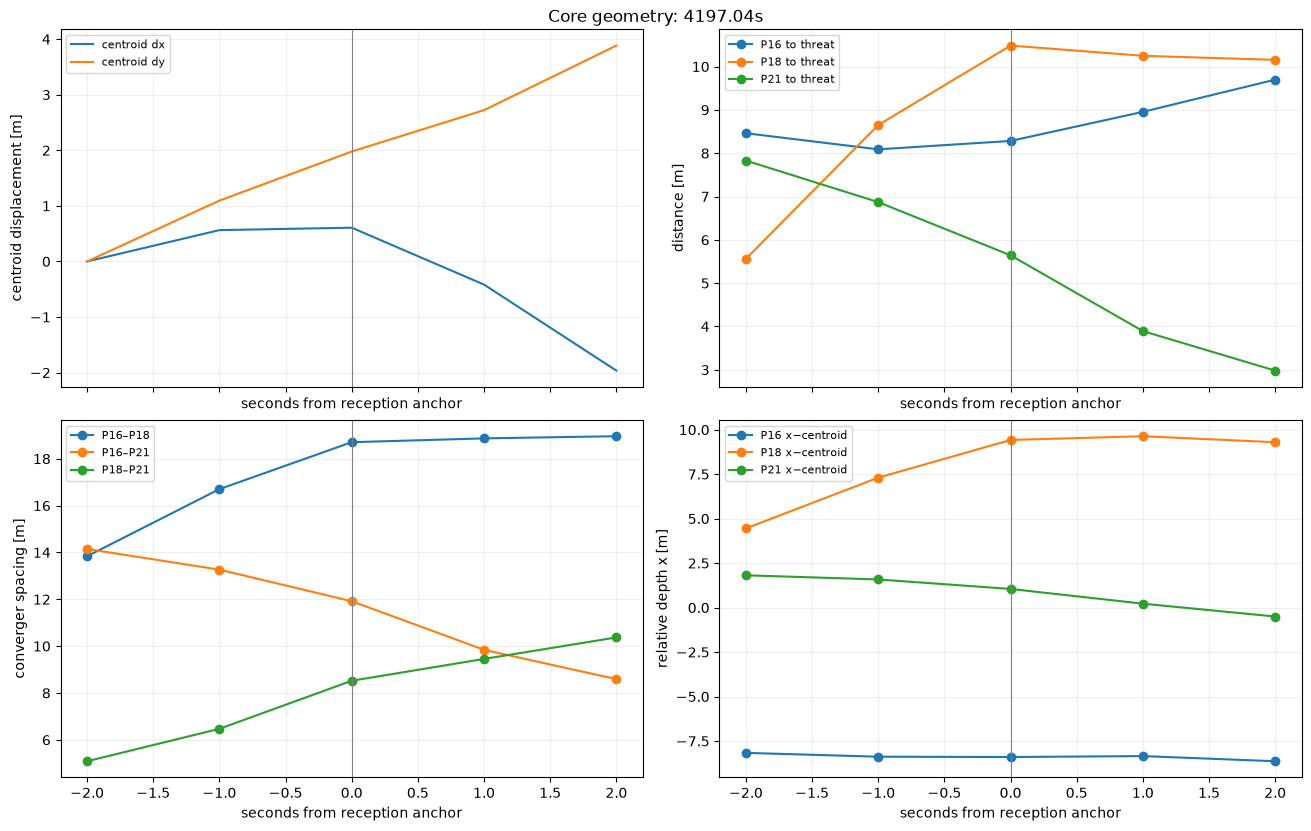

,offset_s,centroid_x_m,centroid_y_m,P16_threat_distance_m,P16_x_minus_centroid_m,P16_y_minus_centroid_m,P18_threat_distance_m,P18_x_minus_centroid_m,P18_y_minus_centroid_m,P21_threat_distance_m,P21_x_minus_centroid_m,P21_y_minus_centroid_m,P16_P18_spacing_m,P16_P21_spacing_m,P18_P21_spacing_m,centroid_dx_from_-2_m,centroid_dy_from_-2_m
0,-2,50.348,25.678,8.461,-8.165,3.434,5.562,4.453,-2.245,7.830,1.817,-6.594,13.837,14.148,5.085,0.000,0.000
1,-1,50.912,26.773,8.089,-8.380,3.712,8.651,7.305,-2.029,6.871,1.583,-5.047,16.702,13.265,6.470,0.564,1.095
2,0,50.956,27.657,8.283,-8.398,3.695,10.484,9.424,-1.988,5.643,1.050,-3.568,18.706,11.917,8.522,0.607,1.978
3,1,49.931,28.401,8.954,-8.345,3.495,10.249,9.634,-2.233,3.893,0.222,-1.353,18.869,9.843,9.453,-0.417,2.723
4,2,48.384,29.563,9.698,-8.635,3.472,10.154,9.297,-2.691,2.981,-0.501,0.709,18.962,8.591,10.371,-1.965,3.884


In [5]:
def core_geometry(c):
    w=case_window(c); dt,at=c['def_team'],c['att_team']; outfield=[p for p in players[dt] if p!=goalkeeper[dt]]; rows=[]
    for off in OFFSETS:
        r=at_offset(w,c,off); cx=np.nanmean([r[f'{dt}_{p}_x'] for p in outfield])*LENGTH; cy=np.nanmean([r[f'{dt}_{p}_y'] for p in outfield])*WIDTH; row={'offset_s':off,'centroid_x_m':cx,'centroid_y_m':cy}
        fx=r[f"{at}_{c['focal']}_x"]*LENGTH; fy=r[f"{at}_{c['focal']}_y"]*WIDTH
        for p in c['convergers']:
            x=r[f'{dt}_{p}_x']*LENGTH; y=r[f'{dt}_{p}_y']*WIDTH; row[f'P{p}_threat_distance_m']=np.hypot(x-fx,y-fy); row[f'P{p}_x_minus_centroid_m']=x-cx; row[f'P{p}_y_minus_centroid_m']=y-cy
        for p,q in itertools.combinations(c['convergers'],2):
            row[f'P{p}_P{q}_spacing_m']=np.hypot((r[f'{dt}_{p}_x']-r[f'{dt}_{q}_x'])*LENGTH,(r[f'{dt}_{p}_y']-r[f'{dt}_{q}_y'])*WIDTH)
        rows.append(row)
    out=pd.DataFrame(rows); out['centroid_dx_from_-2_m']=out.centroid_x_m-out.centroid_x_m.iloc[0]; out['centroid_dy_from_-2_m']=out.centroid_y_m-out.centroid_y_m.iloc[0]; return out
def core_plot(c):
    g=core_geometry(c); fig,axes=plt.subplots(2,2,figsize=(13,8),sharex=True,constrained_layout=True)
    axes[0,0].plot(g.offset_s,g['centroid_dx_from_-2_m'],label='centroid dx'); axes[0,0].plot(g.offset_s,g['centroid_dy_from_-2_m'],label='centroid dy'); axes[0,0].set_ylabel('centroid displacement [m]')
    for p in c['convergers']: axes[0,1].plot(g.offset_s,g[f'P{p}_threat_distance_m'],marker='o',label=f'P{p} to threat')
    axes[0,1].set_ylabel('distance [m]')
    for p,q in itertools.combinations(c['convergers'],2): axes[1,0].plot(g.offset_s,g[f'P{p}_P{q}_spacing_m'],marker='o',label=f'P{p}–P{q}')
    axes[1,0].set_ylabel('converger spacing [m]')
    for p in c['convergers']: axes[1,1].plot(g.offset_s,g[f'P{p}_x_minus_centroid_m'],marker='o',label=f'P{p} x−centroid')
    axes[1,1].set_ylabel('relative depth x [m]')
    for ax in axes.flat: ax.axvline(0,color='grey',lw=.8); ax.grid(alpha=.2); ax.legend(fontsize=8); ax.set_xlabel('seconds from reception anchor')
    fig.suptitle(f"Core geometry: {c['anchor']:.2f}s",y=1.02); plt.show(); return g
core_tables={}
for c in CASES: core_tables[c['anchor']]=core_plot(c); display(core_tables[c['anchor']].round(3))

## Relationships with manually selected other attackers

For every fixed converging defender and every fixed contextual other attacker, the table reports start (−2 s) and anchor distances plus changes in the defender-minus-attacker x/y vector. Positive distance change means separation increased. These combinations are visual context, not assignments; increased separation does not mean an attacker became open or that defending deteriorated.

In [6]:
def other_relationships(c):
    w=case_window(c); dt,at=c['def_team'],c['att_team']; start=at_offset(w,c,-2); anchor=at_offset(w,c,0); rows=[]
    for d in c['convergers']:
        for a in c['others']:
            sx=(start[f'{dt}_{d}_x']-start[f'{at}_{a}_x'])*LENGTH; sy=(start[f'{dt}_{d}_y']-start[f'{at}_{a}_y'])*WIDTH; ex=(anchor[f'{dt}_{d}_x']-anchor[f'{at}_{a}_x'])*LENGTH; ey=(anchor[f'{dt}_{d}_y']-anchor[f'{at}_{a}_y'])*WIDTH
            rows.append({'defender':d,'other_attacker':a,'start_distance_m':np.hypot(sx,sy),'anchor_distance_m':np.hypot(ex,ey),'distance_change_m':np.hypot(ex,ey)-np.hypot(sx,sy),'relative_x_change_m':ex-sx,'relative_y_change_m':ey-sy})
    return pd.DataFrame(rows)
for c in CASES:
    print(f"Case {c['anchor']:.2f}s"); display(other_relationships(c).round(3))

Case 472.48s


,defender,other_attacker,start_distance_m,anchor_distance_m,distance_change_m,relative_x_change_m,relative_y_change_m
0,6,16,22.312,19.570,-2.742,2.697,-2.058
1,6,24,14.067,10.907,-3.160,-2.533,-2.161
2,6,20,14.195,12.336,-1.859,2.863,-0.270
3,8,16,22.794,14.879,-7.916,5.136,7.071
4,8,24,11.423,11.887,0.463,-0.095,6.969
5,8,20,24.559,14.686,-9.873,5.301,8.860
6,10,16,5.672,5.106,-0.566,0.507,0.960
7,10,24,26.144,22.186,-3.959,-4.723,0.857
8,10,20,12.783,10.786,-1.997,0.673,2.749


Case 1230.12s


,defender,other_attacker,start_distance_m,anchor_distance_m,distance_change_m,relative_x_change_m,relative_y_change_m
0,19,6,10.309,9.733,-0.577,-0.936,-1.780
1,19,7,21.934,14.726,-7.208,-0.092,-7.921
2,19,5,7.997,9.472,1.475,-2.048,-1.472
3,20,6,24.230,23.636,-0.594,-0.147,0.679
4,20,7,14.438,14.708,0.270,0.696,-5.462
5,20,5,25.695,24.412,-1.283,-1.259,0.987
6,21,6,20.736,18.902,-1.834,0.046,2.114
7,21,7,7.534,7.808,0.273,0.889,-4.027
8,21,5,25.382,22.977,-2.405,-1.066,2.422


Case 4197.04s


,defender,other_attacker,start_distance_m,anchor_distance_m,distance_change_m,relative_x_change_m,relative_y_change_m
0,16,12,19.915,18.959,-0.956,2.108,3.875
1,16,6,26.409,24.822,-1.587,1.731,-0.035
2,16,3,31.069,31.787,0.719,-0.914,1.093
3,18,12,7.377,1.597,-5.781,7.312,3.871
4,18,6,12.573,6.794,-5.779,6.935,-0.039
5,18,3,21.260,17.116,-4.144,4.290,1.089
6,21,12,11.717,8.070,-3.646,1.575,6.639
7,21,6,14.163,13.397,-0.766,1.198,2.729
8,21,3,25.921,25.028,-0.893,-1.447,3.857


## Opposing-movement cancellation check

The table below lists each converger's −2 s→anchor displacement separately and the all-outfield centroid displacement. Opposite signs among defender components can cancel in the centroid even when individual movements are substantial. This is an audit of arithmetic cancellation, not an exposure or structure metric.

In [7]:
def cancellation_table(c):
    w=case_window(c); dt=c['def_team']; outfield=[p for p in players[dt] if p!=goalkeeper[dt]]; s=at_offset(w,c,-2); e=at_offset(w,c,0); rows=[]
    for p in c['convergers']:
        rows.append({'component':f'converger P{p}','dx_m':(e[f'{dt}_{p}_x']-s[f'{dt}_{p}_x'])*LENGTH,'dy_m':(e[f'{dt}_{p}_y']-s[f'{dt}_{p}_y'])*WIDTH})
    rows.append({'component':'all-outfield centroid','dx_m':np.nanmean([(e[f'{dt}_{p}_x']-s[f'{dt}_{p}_x'])*LENGTH for p in outfield]),'dy_m':np.nanmean([(e[f'{dt}_{p}_y']-s[f'{dt}_{p}_y'])*WIDTH for p in outfield])})
    return pd.DataFrame(rows)
for c in CASES: print(f"Case {c['anchor']:.2f}s"); display(cancellation_table(c).round(3))

Case 472.48s


,component,dx_m,dy_m
0,converger P6,-0.490,-4.061
1,converger P8,1.948,5.069
2,converger P10,-2.681,-1.042
3,all-outfield centroid,-2.133,-2.954


Case 1230.12s


,component,dx_m,dy_m
0,converger P19,-0.435,-1.869
1,converger P20,0.354,0.590
2,converger P21,0.547,2.026
3,all-outfield centroid,0.266,1.286


Case 4197.04s


,component,dx_m,dy_m
0,converger P16,0.374,2.239
1,converger P18,5.578,2.235
2,converger P21,-0.160,5.003
3,all-outfield centroid,0.607,1.978


## Interpretation and stopping point

**472.48 s — local compression with material translation, not the clean centroid-stability counterexample.** From −2 s to the reception anchor, Home6, Home8, and Home10 all reduce distance to Away19, and all three converger-pair spacings contract. The outfield centroid nevertheless moves `−2.133 m` in x and `−2.954 m` in y, so whole-block movement is material. Opposing converger y movements partly cancel—Home6 moves `−4.061 m`, Home8 `+5.069 m`, and Home10 `−1.042 m`—but most inspected relationships to Away16, Away24, and Away20 also tighten rather than showing broad separation elsewhere. This looks consistent with local compression embedded in translation; ball response, general contraction, and rotation remain viable explanations.

**1230.12 s — clearest structural counterexample.** The outfield centroid moves only `+0.266 m` in x and `+1.286 m` in y by the anchor. Away20 and Away21 reduce distance to Home10 substantially, while Away19 initially separates slightly and converges after the anchor. All three defender-pair spacings are lower by the anchor or nearly unchanged, then contract sharply over the next two seconds. Opposing start→anchor movements partly cancel: Away19 moves `−0.435 m` x / `−1.869 m` y, while Away20 and Away21 move in positive x/y directions. Several contextual other-opponent distances tighten, but small increases appear for Away19–Home5, Away20–Home7, and Away21–Home7. These increases are descriptive relational redistribution only; they do not establish exposure, openness, or degraded structure.

**4197.04 s — visual candidate not supported as coherent multi-defender convergence.** The centroid remains fairly stable by the anchor (`+0.607 m` x, `+1.978 m` y), but only Away21 clearly reduces distance to Home10. Away16 is roughly stable and Away18 separates, while converger-pair spacing is mixed and often increases. Most inspected relationships to Home12, Home6, and Home3 tighten instead of separating. The raw cluster therefore does not yield a coherent local-compression phenomenon under these fixed identities. Rotation, shared ball response, and different local relationships are more plausible than a single three-defender convergence account. The example is retained rather than replaced.

Across the fixed cases, substantial local and opponent-relative reorganization **can** occur while the centroid is approximately stable, as at 1230.12 s. It does not occur automatically in every visually dense cluster, and centroid stability alone cannot identify it. Visible changes with other opponents are mixed rather than uniformly exposure-increasing. This supports testing whether defensive structure needs a relational representation, but it does not yet define that representation. **Relational exposure** remains provisional descriptive language. Increased distance alone does not establish openness, lost access, poor defending, or an assignment change. Cover, passing lanes, goal-side position, other defenders, and ball context remain essential alternatives.

This notebook stops after the three fixed visual-first diagnostics. It creates no structure or exposure score, marking assignments, defender states, causal claim, success label, network model, HMM, machine-learning model, optimized threshold, or multi-match extension.